<a href="https://colab.research.google.com/github/chitrangada-juneja/CSC480_HWS/blob/homeworks/HW1_480.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question 2 (b)

In [ ]:
import numpy as np
from collections import Counter


class Node:
    def __init__(self, feature=None, gain=None, left=None, right=None, entropy=None):
        self.feature = feature  # Which feature to split on
        self.gain = gain  # Information gain for the split
        self.left = left  # Left subtree
        self.right = right  # Right subtree
        self.entropy = entropy  # Entropy at this node

class Leaf:
    def __init__(self, label, entropy=None):
        self.label = label  # Predicted class
        self.entropy = entropy  # Entropy at this leaf node

class DecisionTree:
    def __init__(self, max_depth=2):
        self.max_depth = max_depth
        self.tree = None

    def entropy(self, labels):
        """Compute entropy of a label distribution."""
        total = len(labels)
        counts = Counter(labels)
        entropy_value=0
        for count in counts.values():
            if count>0:
              probability=count / total
              entropy_value -= probability * np.log2(probability)

        return entropy_value


    def best_split(self, X, y):
        """Find the best feature to split on based on entropy reduction."""
        best_feature, best_gain = None, 0
        base_entropy = self.entropy(y)

        for feature in range(X.shape[1]):
            left_y = y[X[:, feature] == 0]
            right_y = y[X[:, feature] == 1]
            #calculating the entropy of each split before computing their weighted entropy
            left_entropy = self.entropy(left_y)
            right_entropy = self.entropy(right_y)

            weighted_entropy = (len(left_y)/len(y)) * left_entropy + (len(right_y)/len(y)) * right_entropy
            #computing overall gain (or rather minimizing) entropy with the node under consideration
            info_gain = base_entropy - weighted_entropy

            if info_gain > best_gain:
                #if our current info calculated
                best_gain, best_feature = info_gain, feature

        return best_feature, best_gain

    def build_tree(self, X, y, depth=0):
        """Recursively build the decision tree."""
        if depth >= self.max_depth or len(set(y)) == 1:
            return Leaf(Counter(y).most_common(1)[0][0], entropy=self.entropy(y))  # Return majority class as a Leaf

        best_feature, best_gain = self.best_split(X, y)
        if best_feature is None:
            return Leaf(Counter(y).most_common(1)[0][0], entropy=self.entropy(y))  # No valid split found

        left_indices = (X[:, best_feature] == 0)
        right_indices = (X[:, best_feature] == 1)

        left_subtree = self.build_tree(X[left_indices], y[left_indices], depth + 1)
        right_subtree = self.build_tree(X[right_indices], y[right_indices], depth + 1)

        return Node(feature=best_feature, gain=best_gain, left=left_subtree, right=right_subtree, entropy=self.entropy(y))

    def fit(self, X, y):
        self.tree = self.build_tree(X, y)

    def predict_one(self, x, node):
        if isinstance(node, Leaf):
            return node.label
        return self.predict_one(x, node.left if x[node.feature] == 0 else node.right)

    def predict(self, X):
        return np.array([self.predict_one(x, self.tree) for x in X])

    def print_tree(self, node, feature_names, depth=0):
        """Recursively print the tree structure with additional information."""
        if isinstance(node, Leaf):
            print(f"{'  ' * depth}Leaf: Predicted Label = {node.label}, Entropy calculated= {node.entropy:.4f}")
        else:
            print(f"{'  ' * depth}Node: Feature is  {feature_names[node.feature]}, Information Gained = {node.gain:.4f}, Entropy calculated = {node.entropy:.4f}")
            print(f"{'  ' * depth}  Question: Is {feature_names[node.feature]} == 0?")
            print(f"{'  ' * depth}  Left Subtree:")
            self.print_tree(node.left, feature_names, depth + 1)
            print(f"{'  ' * depth}  Right Subtree:")
            self.print_tree(node.right, feature_names, depth + 1)

# Feature names corresponding to the dataset
feature_names = [ "Easy?", "AI?", "Sys?", "Thy?", "Morning?","Rating"]

# Data from the new table
data = np.array([
    [1, 1, 0, 1, 0, 2],
    [1, 1, 0, 1, 0, 2],
    [0, 1, 0, 0, 0, 2],
    [0, 0, 0, 1, 0, 2],
    [0, 1, 1, 0, 1, 2],
    [1, 1, 0, 0, 0, 1],
    [1, 1, 0, 1, 0, 1],
    [0, 1, 0, 1, 0, 1],
    [0, 0, 0, 0, 1, 0],
    [1, 0, 0, 1, 1, 0],
    [0, 1, 0, 1, 0, 0],
    [1, 1, 1, 1, 1, 0],
    [1, 1, 1, 0, 1, -1],
    [0, 0, 1, 1, 0, -1],
    [0, 0, 1, 0, 1, -1],
    [1, 0, 1, 0, 1, -1],
    [0, 0, 1, 1, 0, -2],
    [0, 1, 1, 0, 1, -2],
    [1, 0, 1, 0, 0, -2],
    [1, 0, 1, 0, 1, -2]
])

# Convert labels: {2, 1, 0} → Positive (1), {-1, -2} → Negative (0)
y = np.array([1 if label >= 0 else 0 for label in data[:, -1]])
X = data[:, :-1]

# Train the decision tree
dt = DecisionTree(max_depth=2)
dt.fit(X, y)

# Print the tree with detailed information
print("Decision Tree Structure:")
dt.print_tree(dt.tree, feature_names)


Decision Tree Structure:
Node: Feature Sys?, Information Gain = 0.6100, Entropy = 0.9710
  Question: Is Sys? == 0?
  Left Subtree:
  Leaf: Predicted Label = 1, Entropy = 0.0000
  Right Subtree:
  Node: Feature AI?, Information Gain = 0.3219, Entropy = 0.7219
    Question: Is AI? == 0?
    Left Subtree:
    Leaf: Predicted Label = 0, Entropy = 0.0000
    Right Subtree:
    Leaf: Predicted Label = 1, Entropy = 1.0000


Kendal Shae McCall helped me understand and break down the code for Question 3


In [ ]:
3b

In [61]:
def sample(m):
    a = [[0.1, 0.2, 0.2], [0.2, 0.4, 0.8], [0.2, 0.8, 0.9]]
    x_1 = np.random.uniform(0, 1, m)
    x_2 = np.random.uniform(0, 1, m)
    i_x = []
    j_x = []

    #populating our i(x) and j(x) values

    for num in x_1:
      if num < (1/3):
        i_x.append(1)
      elif num >= (1/3) and num < (2/3):
        i_x.append(2)
      else:
        i_x.append(3)


    for num in x_2:
      if num < (1/3):
        j_x.append(1)
      elif num >= (1/3) and num < (2/3):
        j_x.append(2)
      else:
        j_x.append(3)

    #computing probability according to given matrix
    probability = []
    x = []
    for i in range(m):
      x.append((i_x[i], j_x[i]))
      probability.append(a[i_x[i] - 1][j_x[i] - 1])
    y = np.random.binomial(1, probability)
    return(x, y)


#Drawing 10,000 points from D and calling them a test set
x_test, y_test = sample(10000)

3c


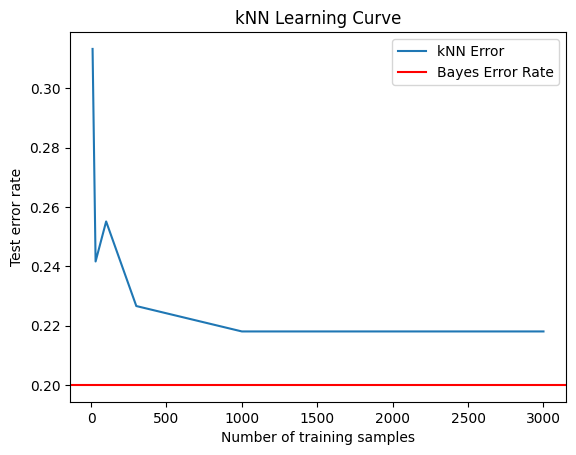

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier


M = [10, 30, 100, 300, 1000, 3000]
trial_count = 5
k = 4
bayes_error_rate = 0.2
ave_errors = []

#function that creates the k-NN classifier and fits the model, asking it to
#predict on test set x
def knn_error(x_train, y_train, x_test, y_test, k):
    model = KNeighborsClassifier(n_neighbors = k)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    error = np.mean(y_pred != y_test)
    return error


#for each trial in the range , we compute and train our sets

for trial in range(trial_count):

  # calling the "one trial" as defined in the question
    x, y = sample(3000)
    m_errors = []
    for m in M:
        x_train = x[:m]
        y_train = y[:m]
        error = knn_error(x_train, y_train, x_test, y_test, k)
        m_errors.append(error)
    ave_errors.append(m_errors)

#averaging out the errors and plotting
ave_errors = np.array(ave_errors)
m_error_ave = ave_errors.mean(axis=0)

plt.plot(M, m_error_ave, label='kNN Error', marker="o")
plt.axhline(y = bayes_error_rate, color='r', label='Bayes Error Rate')
plt.xlabel('Number of training samples')
plt.ylabel('Test error rate')
plt.title('kNN Learning Curve')
plt.legend()
plt.show()

3d


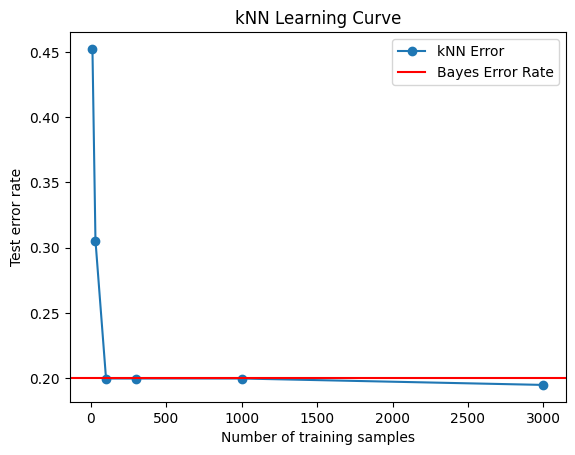

In [68]:
# choose and change the k value for each k in K = {1, 2, 4, 8, 16, 32, 64}
k = 64
ave_errors_k = []

def knn_error(x_train, y_train, x_test, y_test, k):
    model = KNeighborsClassifier(n_neighbors = k)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    error = np.mean(y_pred != y_test)
    return error



#for each trial in the range , we compute and train our sets

for trial in range(trial_count):
    x, y = sample(3000)
    m_errors = []
    for m in M:
      if k >= m:
        #if k >m, we force k=m since its impossible to compute it when k >=m
        k = m
      x_train = x[:m]
      y_train = y[:m]
      error = knn_error(x_train, y_train, x_test, y_test, k)
      m_errors.append(error)
    ave_errors_k.append(m_errors)

#averaging out the errors and plotting

ave_errors_k = np.array(ave_errors_k)
m_error_ave = ave_errors_k.mean(axis=0)

plt.plot(M, m_error_ave, label='kNN Error', marker="o")
plt.axhline(y = bayes_error_rate, color='r', label='Bayes Error Rate')
plt.xlabel('Number of training samples')
plt.ylabel('Test error rate')
plt.title('kNN Learning Curve')
plt.legend()
plt.show()